# 我使用了什么库？

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
# 需要导入的库

import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc


# 然后，我要干什么？

首先,要了解需要解决什么问题:

**Q**: 什么是分类问题？

**Q**: 什么是二元分类（举例）？

然后和**回归问题**一样，首先要解决**数据生成**和**数据准备**的问题

# 分类问题

**Q**: 分类问题的数据是什么样的？（描述特征和标签存储内容的意义）


## 数据生成

**Q**: 数据生成大体上有几个相关的系数？

**Q**: 数据生成后的首要步骤是什么？

**Q**: 数据生成后的第二个步骤是什么？针对的数据范围是？（Tips: 梯度等高线的形状）

结合代码:

**Q**: 如何制造一组二元分类的数据？参数都是什么意思？

**Q**: 如何拆分二元数据？

**Q**: 复习如何标准化一维数据的？现在如何标准化二维数据？

[-0.0551441  -0.03733246] 1
(100, 2) (100,)
(80, 2) (80,)
(20, 2) (20,)


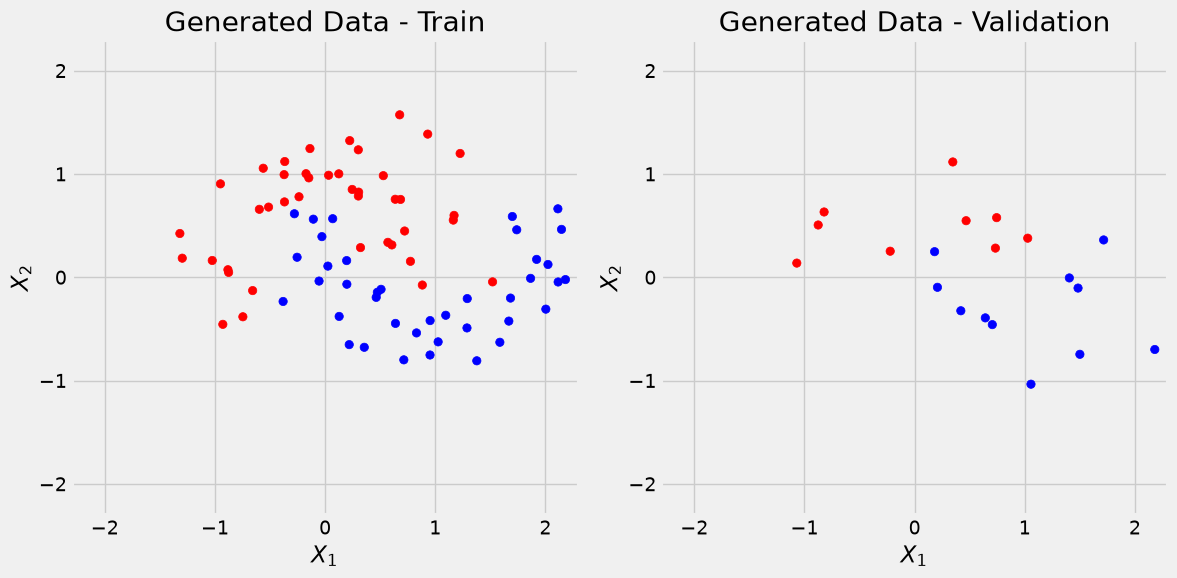

In [3]:
# 程序3-1: 生成分类数据

# 参数: 数量,噪声,种子
x,y = make_moons(n_samples=100,noise=0.3,random_state=0)

# 拆分数据
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,random_state=13)

print(x_train[0],y_train[0])

print(x.shape,y.shape)
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)

# 验证和可视化
from plots.chapter3 import *
fig = figure1(x_train, y_train, x_val, y_val)

## 标准化数据

参考ch00:标准化-归一化-缩放,复习

**Q**: 标准化后的均值和标准差有什么特点？

**Q**: 如何对数据集进行标准化？（均值，标准差，和缩放公式）有什么注意事项？

**Q**: 为什么标准化后的特征对学习有好处？

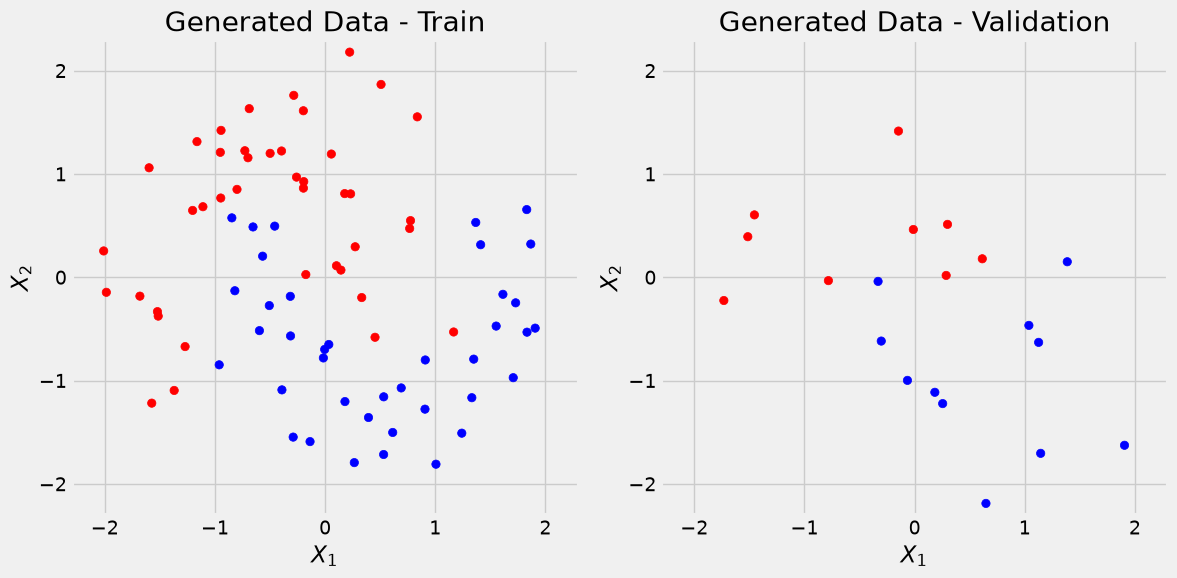

In [4]:
# 程序3-2: 标准化

sc = StandardScaler()
sc.fit(x_train)

x_train = sc.transform(x_train)
x_val = sc.transform(x_val)

fig = figure1(x_train, y_train, x_val, y_val)

## 数据准备

**Q**: 在以前的经历中,数据准备要做哪些事？

结合代码:

**Q**: `reshape`的作用是什么？

**Q**: shuffle与否的标准是什么?

In [5]:
# 程序3-3: 数据准备

# 设置种子
torch.manual_seed(13)

# 构建张量
#print(y_train.shape,y_train.reshape(-1,1).shape)
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train.reshape(-1,1)).float()

x_val_tensor = torch.as_tensor(x_val).float()
y_val_tensor = torch.as_tensor(y_val.reshape(-1,1)).float()

# 构建dataset
train_dataset  = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# 构建dataloader

train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)

# 然后，我要干什么？

在数据工作完成后,之后便是要了解使用的模型，不同于回归时简单的线性回归模型,对于分类问题,使用的是所谓**逻辑斯提(logistic)回归模型**
- 它如何处理分类问题？
- **logit**是什么？

这里设计很多概念，然后: 会去了解与之相关的损失函数：**二元交叉熵损失**，还会讨论不平衡数据集的处理方法

# 模型

## 逻辑斯特回归

**Q**: 复习:线性回归的公式是什么？

**Q**: 如何将线性回归模型映射成离散标签？（以二元为例，公式）

**Q**: `logit(z)`如何用向量表示？

阅读笔记:

**Q**: 在书中,什么是logit(z),什么是logit？

**Q**: logit和线性回归的区别？其不确定性从何而来？

**Q**: 概率在其中的作用是什么？

---


**Q**: 比值比是什么？其作用是什么？图像是什么？

**Q**: 对数比值比是什么？图像是什么？

**Q**: logit值映射到概率的函数需要什么特征？为什么？


3.0 0.3333333333333333


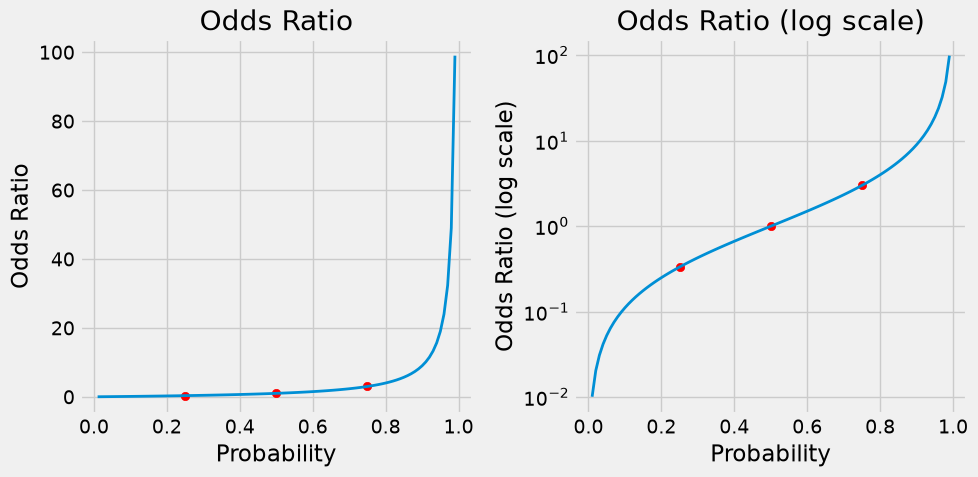

In [6]:
# 程序3-4: 比值比（赔率）
def odds_ratio(prob):
    return prob / (1 - prob)

p = .75
q = 1 - p
print(odds_ratio(p), odds_ratio(q))

# 可视化
fig = figure2(p)

1.0986122886681098 -1.0986122886681098


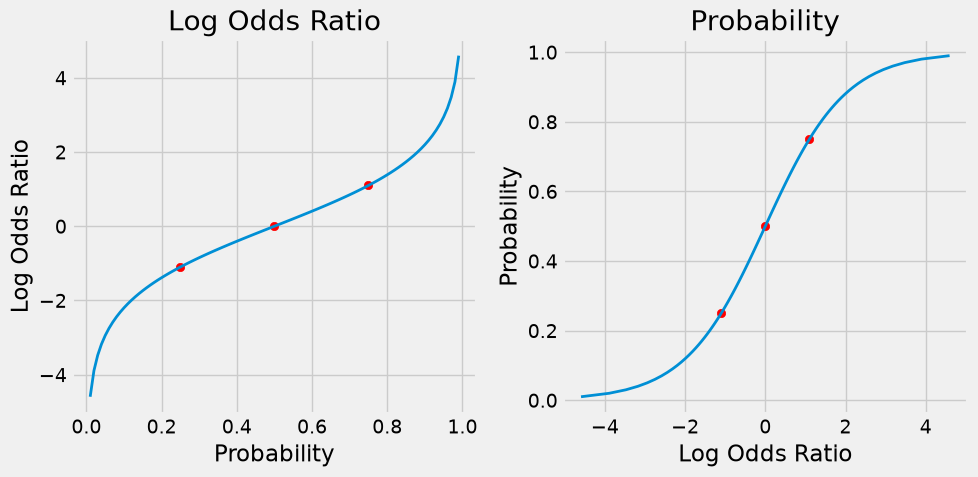

In [7]:
# 程序3-5: 对数比值比和概率
def log_odds_ratio(prob):
    return np.log(odds_ratio(prob))

p = .75
q = 1 - p
print(log_odds_ratio(p), log_odds_ratio(q))

fig = figure3(p)

### note-ch03-1

这里要解释的问题是： 如何将线性回归模型和概率挂钩？

**首先**，线性回归模型是线性的，需要先映射到离散的标签上

$$
\Large
y =
\begin{cases}
1,\ \text{if }b + w_1x_1 + w_2x_2 \ge 0
\\
0,\ \text{if }b + w_1x_1 + w_2x_2 < 0
\end{cases}
$$

对于该函数来说，`logit(z)`,`z`就是不等是左边的值，又称为**logit值**

**接着**，该值貌似与线性回归相同且无噪声，那么其**不确定性**如何体现？

对于该函数，我们不说某个点的函数值是哪个离散标签，而是统一返回在该数据点的情况下，结果属于正类的概率，简言就是该**数据点属于正类的概率**。

---

注意，这里的**目标其实是要把`z`的取值映射到概率上**，在上述情况下
- 越大的正`logit`值应该分配较高的概率
- 越大的负`logit`值应该分配较低的概率
- 0.5概率的情况发生在`z=0`的情况上



## Sigmoid函数

**Q**: logit如何通过对数比值比映射到概率？


结合代码:

**Q**: torch的sigmoid如何使用？（两种方法）第二种方法的作用是？

In [8]:
# 程序3-6: sigmoid

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p = .75
q = 1 - p
print(sigmoid(log_odds_ratio(p)), sigmoid(log_odds_ratio(q)))

0.75 0.25


tensor(0.7500) tensor(0.2500)


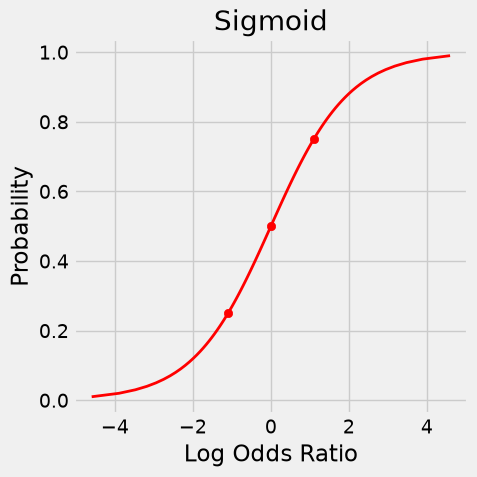

In [9]:
# 程序3-7: torch的sigmoid(只展示方法1)

print(torch.sigmoid(torch.tensor(1.0986)), torch.sigmoid(torch.tensor(-1.0986)))

fig = figure4(p)

## 非线性函数

**Q**: sigmoid函数有什么特点？

**Q**: 激活函数是什么？有什么特点？

**Q**: 非线性函数的意义？

结合代码:

**Q**: 逻辑斯蒂回归如何用层来实现？

In [10]:
# 程序3-8: 逻辑斯蒂回归

torch.manual_seed(42)

model1 = nn.Sequential()
model1.add_module("linear",nn.Linear(2,1))
model1.add_module("sigmoid",nn.Sigmoid())

print(model1.state_dict())

OrderedDict([('linear.weight', tensor([[0.5406, 0.5869]])), ('linear.bias', tensor([-0.1657]))])


# 损失函数

**Q**: 二元分类的损失函数是什么？（别名:对数损失,BCE）

**Q**: BCE的公式是什么？（直观方法和通用公式）

**Q**: 对于负类的概率如何处理？

结合代码:

**Q**: BCE的公式是什么？（直观方法和通用公式）

**Q**: nn的BCE如何定义和使用？参数的意义？




In [11]:
# 程序3-9: BCE损失函数 (直观)

dummy_labels = torch.tensor([1.,0.])
dummy_preds = torch.tensor([.9,.2])

print(dummy_labels == 1,dummy_labels == 0)
# 正类
pos_pred = dummy_preds[dummy_labels == 1]
first_sum = torch.log(pos_pred).sum()

# 负类
neg_pred = dummy_preds[dummy_labels == 0]
second_sum = torch.log(1-neg_pred).sum()

n_total = dummy_labels.size(0)

loss = -(first_sum + second_sum)/n_total

print(loss)



tensor([ True, False]) tensor([False,  True])
tensor(0.1643)


In [12]:
# 程序3-10: BCE损失函数 (通用)

summation = torch.sum(
    dummy_labels * torch.log(dummy_preds) +
    (1 - dummy_labels) * torch.log(1 - dummy_preds)
)
loss = -summation / n_total
print(loss)


tensor(0.1643)


In [13]:
# 程序3-10: BCE损失函数 (封装函数)

loss_fn = nn.BCELoss(reduction='mean')


# 注意:预测在前,labels在后

print(loss_fn(dummy_preds, dummy_labels))

print(loss_fn(dummy_labels, dummy_preds))

tensor(0.1643)
tensor(15.0000)


# 不平衡的数据集

## BCEWithLogitsloss

结合代码

**Q**: `BCEWithLogitsloss`和`BCELoss`的区别是什么？

**Q**: 对层的设计有什么影响？

**Q**: `BCEWithLogitsloss`参数的都有什么意义？

In [14]:
# 程序3-11: BCEWithLogitsloss损失函数 (封装函数)

loss_fn_logits = nn.BCEWithLogitsLoss(reduction='mean')

logit1 = log_odds_ratio(.9)
logit2 = log_odds_ratio(.2)


dummy_labels = torch.tensor([1.,0.])
dummy_logits = torch.tensor([logit1,logit2])

print(dummy_logits)

loss = loss_fn_logits(dummy_logits, dummy_labels)

print(loss)


tensor([ 2.1972, -1.3863], dtype=torch.float64)
tensor(0.1643)


## 不平衡的数据集

**Q**: 如何是不平衡的数据集，举例说明？

**Q**: `BCEWithLogitsloss`的`pos_wegiht`参数如何设置（公式，张量的长度）？

结合代码:

**Q**: `BCEWithLogitsloss`对于`pos_wegiht`的计算有什么怪癖？

In [15]:
# 程序3-12: 不平衡数据集的BCEWithLogitsloss

dummy_imb_labels = torch.tensor([1.0, 0.0, 0.0, 0.0])
dummy_imb_logits = torch.tensor([logit1, logit2, logit2, logit2])


# 计算参数
n_neg = (dummy_imb_labels == 0).sum().float()
n_pos = (dummy_imb_labels == 1).sum().float()

pos_wight = (n_neg / n_pos).view(1,)

print(pos_wight)


# 怪癖？
loss_fn_imb = nn.BCEWithLogitsLoss(reduction='mean',pos_weight=pos_wight)

loss = loss_fn_imb(dummy_imb_logits, dummy_imb_labels)
print(loss)


# 怪癖的处理方法
loss_fn_imb_sum = nn.BCEWithLogitsLoss(reduction='sum',pos_weight=pos_wight)

loss = loss_fn_imb_sum(dummy_imb_logits, dummy_imb_labels)

loss = loss / (pos_wight * n_pos + n_neg)

print(loss)



tensor([3.])
tensor(0.2464)
tensor([0.1643])


# 然后，我要干什么？

接下来要用之前的模型配置和模型训练解决分类的问题

# 模型配置和模型训练

结合代码:

**Q**: 看看什么变了，什么没变？

In [16]:
# 程序3-13: 模型配置

lr = 0.1

torch.manual_seed(42)

model = nn.Sequential()
model.add_module('linear',nn.Linear(2,1))

optim = optim.SGD(model.parameters(), lr=lr)

loss_fn = nn.BCEWithLogitsLoss()

OrderedDict([('linear.weight', tensor([[ 1.1806, -1.8693]])), ('linear.bias', tensor([-0.0591]))])


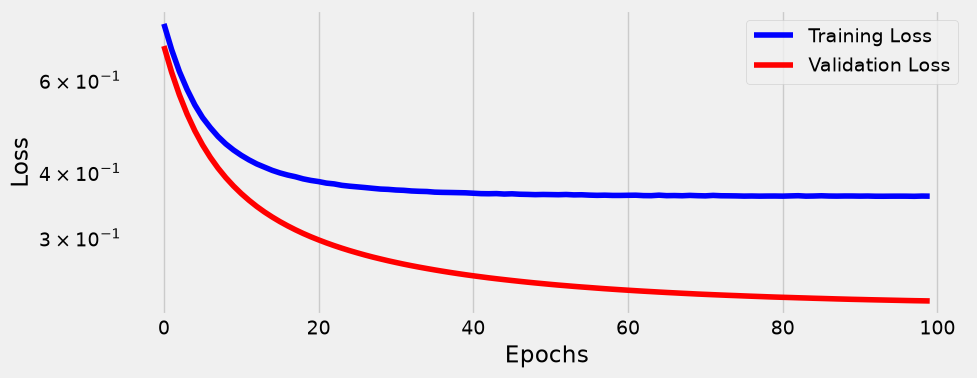

In [17]:
# 程序3-14: 模型训练
from runtest.StepClass.v0 import StepByStep



n_epochs = 100

sbs = StepByStep(model,loss_fn,optim)
sbs.set_loaders(train_loader,val_loader)
sbs.train(n_epochs=n_epochs)

print(model.state_dict())

fig = sbs.plot_losses()

## 模型预测和简单的类别判断

**Q**: 如何做类别判断？（两种输出下）

结合代码:

**Q**: 前向预测返回的是什么？

In [18]:
# 程序3-15: 模型预测

# 前向预测
prediction = sbs.predict(x_train_tensor[:4])
print(prediction)


# 分类（按之前随便定下的0.5来划分）
classess = (prediction>=0).astype(np.int8)
print(classess)

[[ 0.20345592]
 [ 2.9444451 ]
 [ 3.6933177 ]
 [-1.2334073 ]]
[[1]
 [1]
 [1]
 [0]]


# 然后，我要干什么？

接下来，要关注**决策边界**的问题，从直观的角度看为什么多层神经网络才能解决分类问题？

然后，就会关注**分类阈值**和**混淆矩阵**以及一些常见的**分类指标**



# 决策边界

**Q**: 从公式角度分析，为什么`z=0`就意味着决策边界?

结合代码:

**Q**: 解释三张图的含义？（注意红蓝代表的意义）

**Q**: 逻辑斯蒂回归如何分隔两个类别？

**Q**: 损失和类别的可分离成都有什么关系？

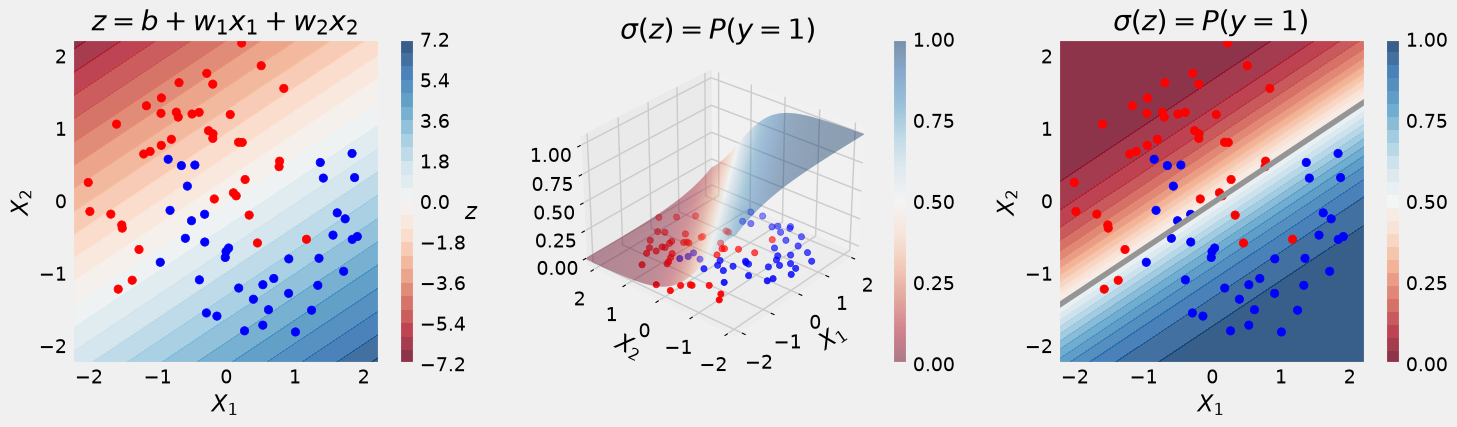

In [19]:
# 可视化训练集的分布情况

fig = figure7(x_train, y_train, sbs.model, sbs.device)

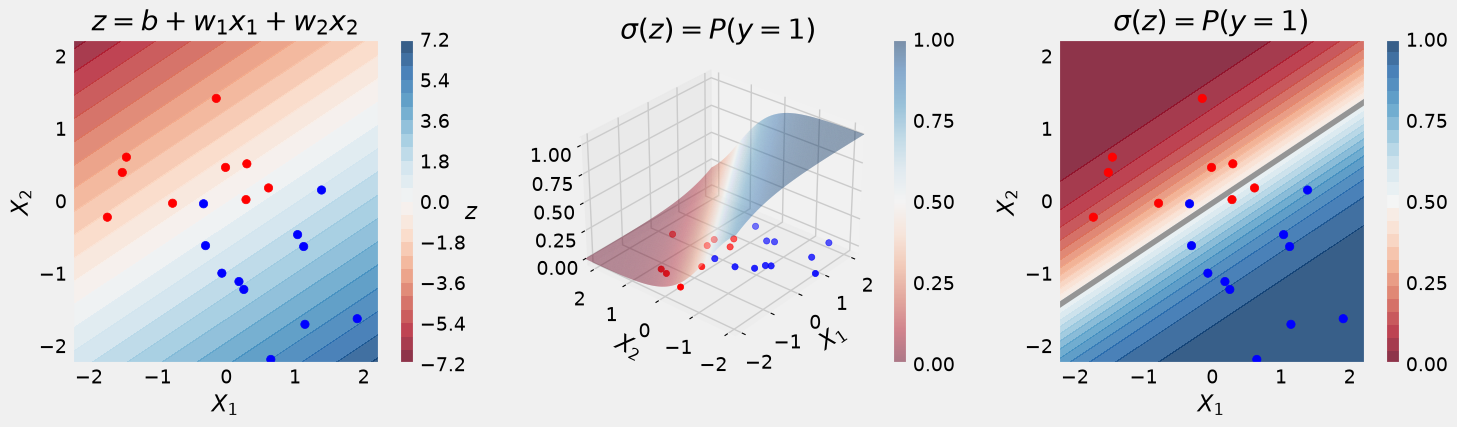

In [20]:
# 可视化验证集的分布情况

fig = figure7(x_val, y_val, sbs.model, sbs.device)

## 如何分离数据点

**Q**: 一维的数据是可分离的嘛？（作图表示）

**Q**: 如何将不可分离的数据变成可分离的？

**Q**: 对应到神经网络中是如何实现的？

结合代码:

**Q**: 多层神经网络需要什么特殊函数的参与才有效？否则等效于什么模型？

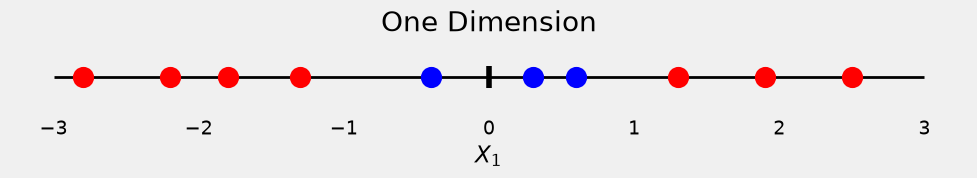

In [21]:
# 可视化一维数据的情况

x = np.array([-2.8, -2.2, -1.8, -1.3, -.4, 0.3, 0.6, 1.3, 1.9, 2.5])
y = np.array([0., 0., 0., 0., 1., 1., 1., 0., 0., 0.])

fig = one_dimension(x, y)

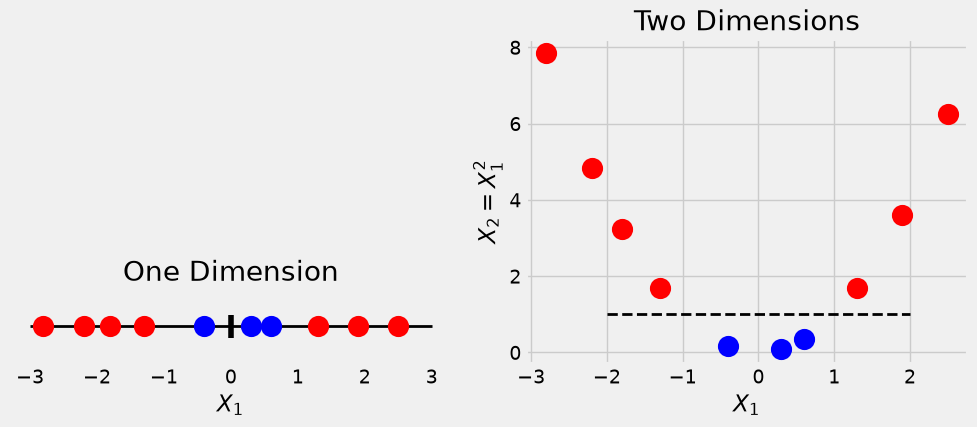

In [22]:
# 可视化多维数据的情况

fig = two_dimensions(x, y)

In [23]:
# 放在神经网络中的实现

model = nn.Sequential()
model.add_module('hidden', nn.Linear(2, 10))
model.add_module('activation', nn.ReLU())
model.add_module('output', nn.Linear(10, 1))
model.add_module('sigmoid', nn.Sigmoid())

loss_fn = nn.BCELoss()

# 分类阈值


## 决策边界

结合图片:

**Q**: 决策边界是什么意思？

**Q**: 数据点的不同形式代表了什么意思？

结合代码:

**Q**: `squeeze`函数的作用是什么？

[[0.40727958]
 [0.67678314]
 [0.07043092]] [0.40727958 0.67678314 0.07043092]


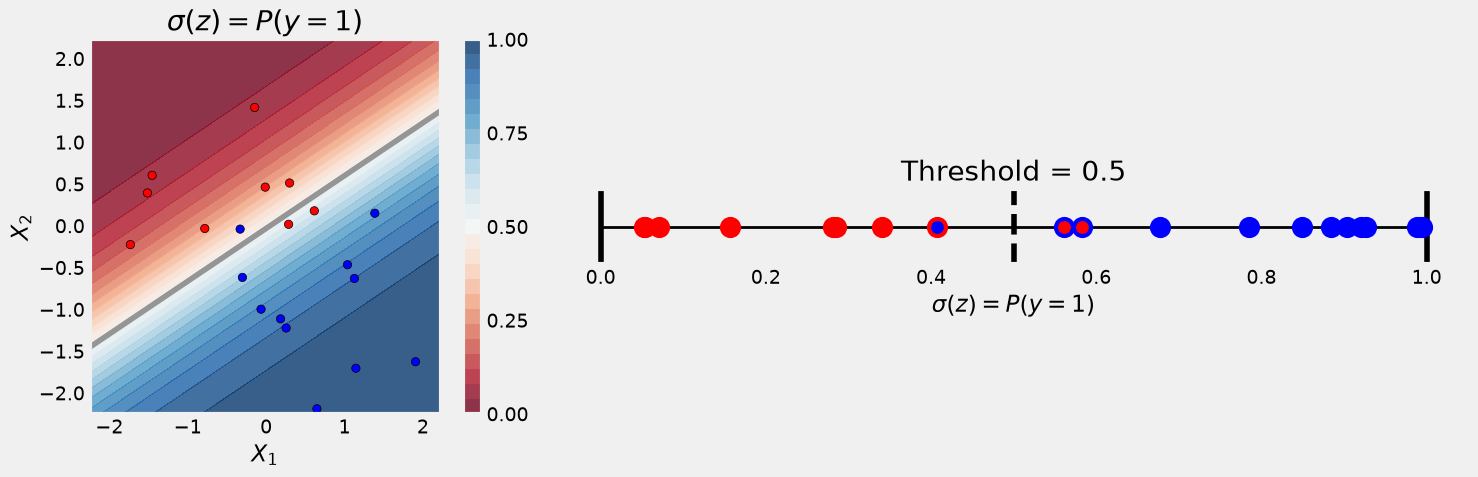

In [24]:
# 50%阈值分类的可视化

logits_val = sbs.predict(x_val)

tmp_val = sigmoid(logits_val)

# squeeze的作用
print(tmp_val[:3],tmp_val.squeeze()[:3])

probabilities_val = tmp_val.squeeze()
threshold = 0.5

fig = figure9(x_val, y_val, sbs.model, sbs.device, probabilities_val, threshold)

## 混淆矩阵

结合图片:

**Q**: 解释**混淆矩阵**的四个象限是什么？

结合代码:

**Q**: 如何生成混淆矩阵？

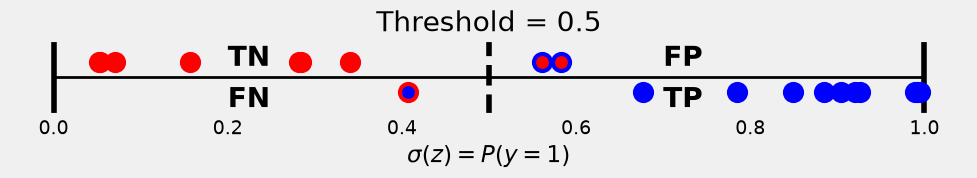

In [25]:
# 可视化混淆矩阵

fig = figure10(y_val, probabilities_val, threshold, 0.04, True)


In [26]:
# 程序3-16: 构建混淆矩阵

print(y_val.shape,probabilities_val.shape)
print(y_val[:3],probabilities_val[:3])

cm_thresh50 = confusion_matrix(y_val, (probabilities_val >= .5))
print(cm_thresh50)

# 以Scikit-Learn约定展示四个维度
def split_cm(cm):
    # 阴性在概率线上方
    actual_negative = cm[0]
    # 阴性第一列
    tn = actual_negative[0]
    # 阳性第二列
    fp = actual_negative[1]

    # 阳性在概率线下方
    actual_positive = cm[1]
    # 阴性第一列
    fn = actual_positive[0]
    # 阳性第二列
    tp = actual_positive[1]

    return tn, fp, fn, tp

print(split_cm(cm_thresh50))

(20,) (20,)
[1 1 0] [0.40727958 0.67678314 0.07043092]
[[ 7  2]
 [ 1 10]]
(np.int64(7), np.int64(2), np.int64(1), np.int64(10))


## 各种指标

### 真假阳性率

**Q**: 说明真阳性率，假阳性率的公式（Tips:分母是整行）

**Q**: 真阳性率代表了什么？

**Q**: 真阳性率的别名是什么？

**Q**: 如果FN对应用不利，应该改进什么？（Tips: 安检）

---

**Q**: 假阳性率代表了什么？

**Q**: 如果FP对应用不利，应该改进什么？（Tips: 投资阳性盈利）

---

**Q**: 分析阈值对四个象限的影响来反思TPR和FPR的权衡？

结合代码:

**Q**: 如何实现真假阳性率计算？

In [27]:
# 程序3-17: 真假阳性率计算

def tpr_fpr(cm):
    tn, fp, fn, tp = split_cm(cm)

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    return tpr, fpr
tpr_fpr(cm_thresh50)

(np.float64(0.9090909090909091), np.float64(0.2222222222222222))

### 精确率和召回率和准确率

**Q**: 什么是召回率？（Tips:实际条件下）

**Q**: 什么是精确率？（Tips:预测条件下）

**Q**: 什么是准确率?

**Q**: 准确率什么时候会产生误导？

**Q**: 如果FP不利,应该改进什么？


结合代码:

**Q**: 如何实现精确率和召回率？

In [28]:
# 程序3-18: 精确率和召回率计算

def precision_recall(cm):
    tn, fp, fn, tp = split_cm(cm)

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    return precision, recall

print(precision_recall(cm_thresh50))



(np.float64(0.8333333333333334), np.float64(0.9090909090909091))


# 权衡和曲线

**Q**: ROC曲线和PR曲线是什么？

结合图片:

**Q**: 阈值的变化对指标的变化会产生什么影响？

**Q**: 阈值1和0对应曲线的什么位置

**Q**: PR曲线最右侧代表了什么？

结合代码:

**Q**: 如何绘制两种曲线(非自己实现)？

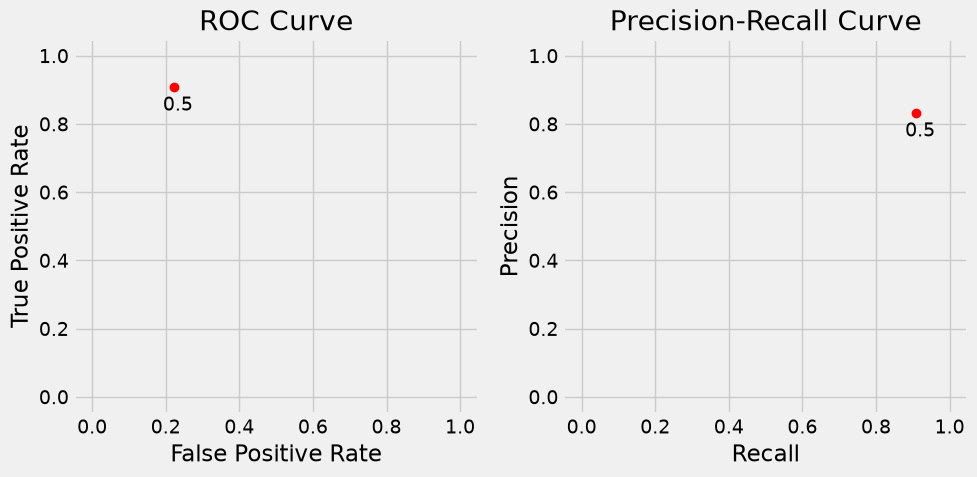

In [29]:
# 50%阈值的数据

fig = eval_curves_from_probs(y_val, probabilities_val, [.5], annot=True)

[[ 6  3]
 [ 0 11]]


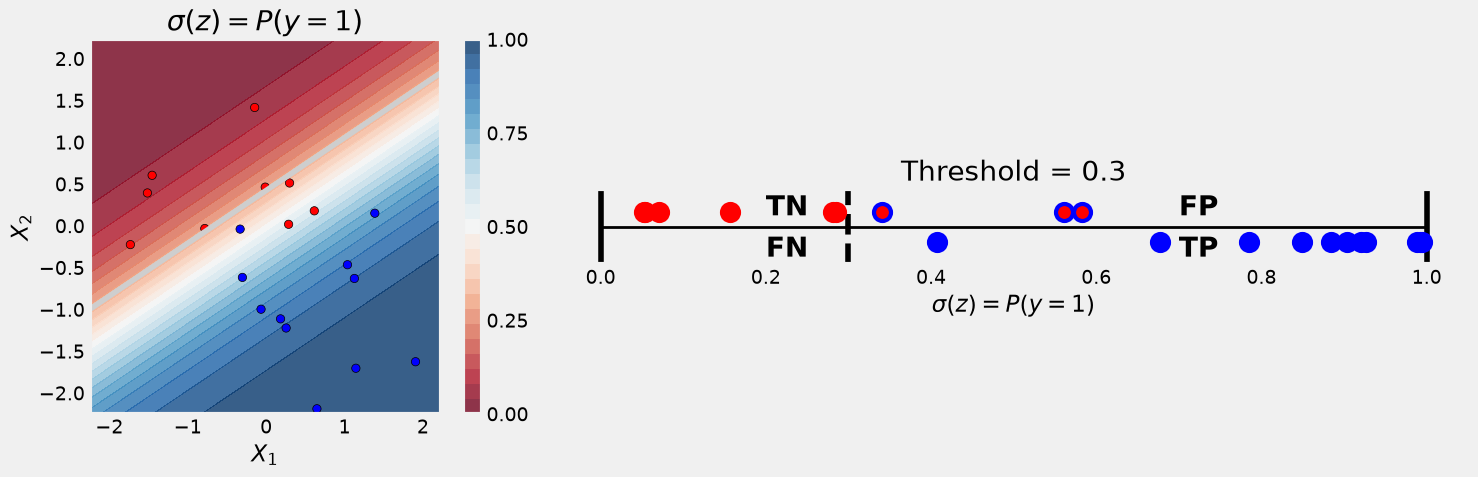

In [30]:
# 30%阈值的分布

print(confusion_matrix(y_val, (probabilities_val >= 0.3)))

fig = figure9(x_val, y_val, sbs.model, sbs.device, probabilities_val, threshold=0.3, shift=0.04, annot=True)

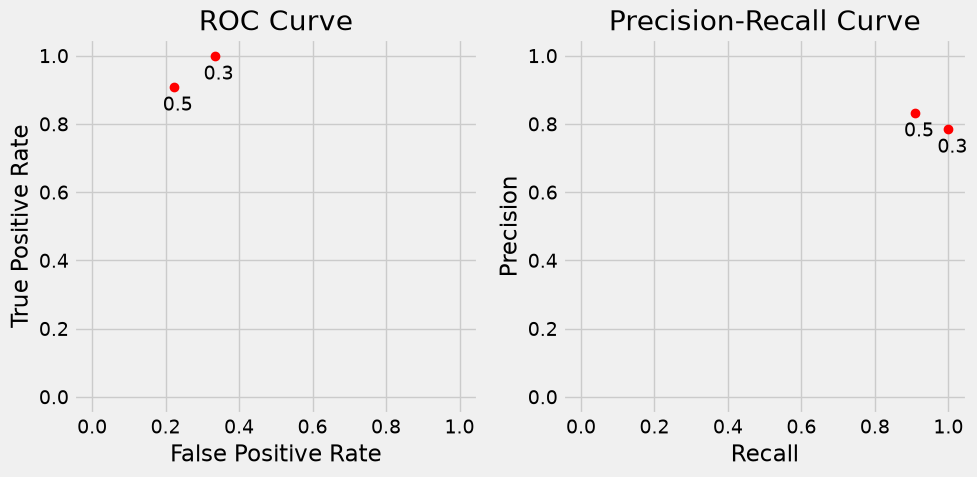

In [31]:
# 30%阈值的数据
fig = eval_curves_from_probs(y_val, probabilities_val, [.3, .5], annot=True)

----

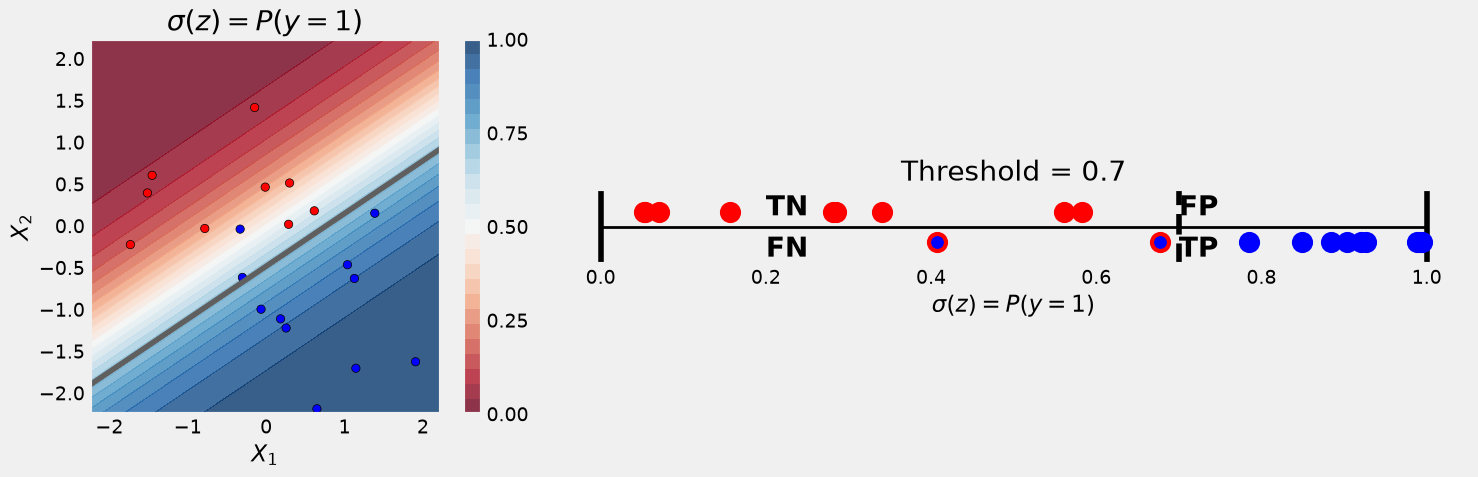

In [32]:
# 70%阈值的分布

fig = figure9(x_val, y_val, sbs.model, sbs.device, probabilities_val, threshold=0.7, shift=0.04, annot=True)

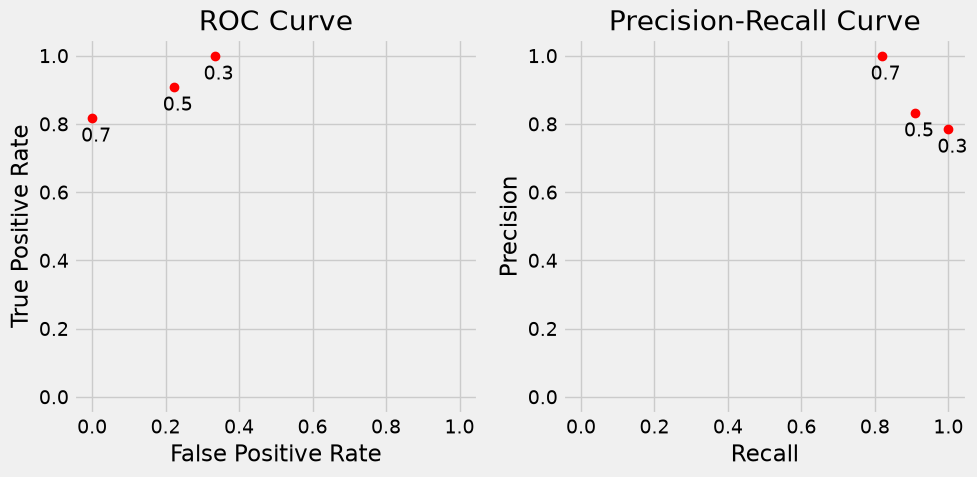

In [33]:
# 70%阈值的数据

fig = eval_curves_from_probs(y_val, probabilities_val, [.3, .5, .7], annot=True)

----

d:\projectCode\AI\PyTorchStepByStep\plots\chapter3.py:49: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


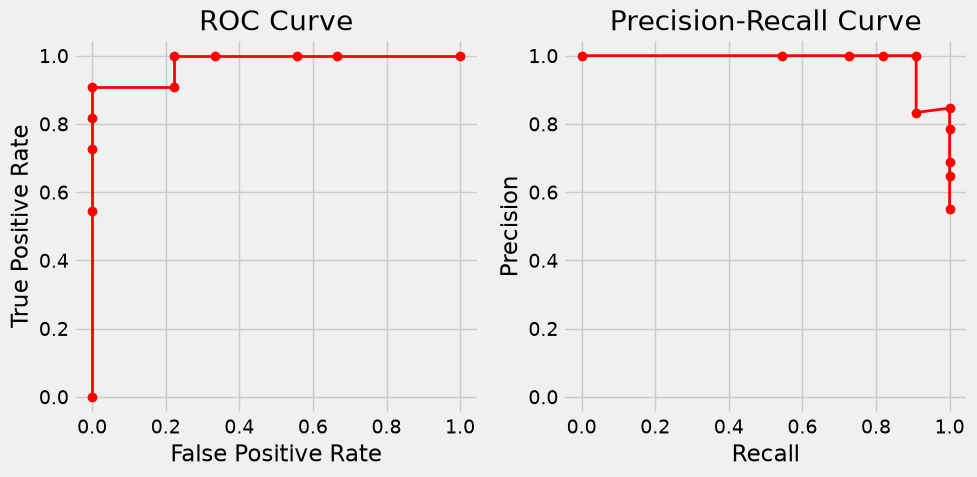

In [34]:
# 10%的倍数的数据

threshs = np.linspace(0.,1,11)

fig = figure17(y_val, probabilities_val, threshs)

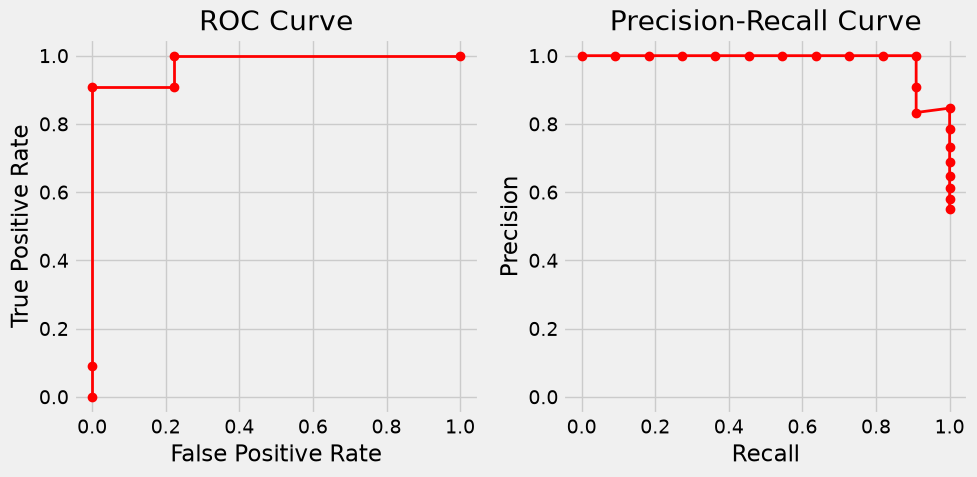

In [35]:
# 程序3-19: 绘制ROC和PR
fpr, tpr, thresholds1 = roc_curve(y_val, probabilities_val)
prec, rec, thresholds2 = precision_recall_curve(y_val, probabilities_val)

fig = eval_curves(fpr, tpr, rec, prec, thresholds1, thresholds2, line=True)

## 精确率的调整

**Q**: 提高阈值阈值对精确率有什么影响？有什么特殊情况？

## 最好的情况和最坏的情况

结合图片:

**Q**: 说明最好的情况和最坏情况的曲线是什么样的？

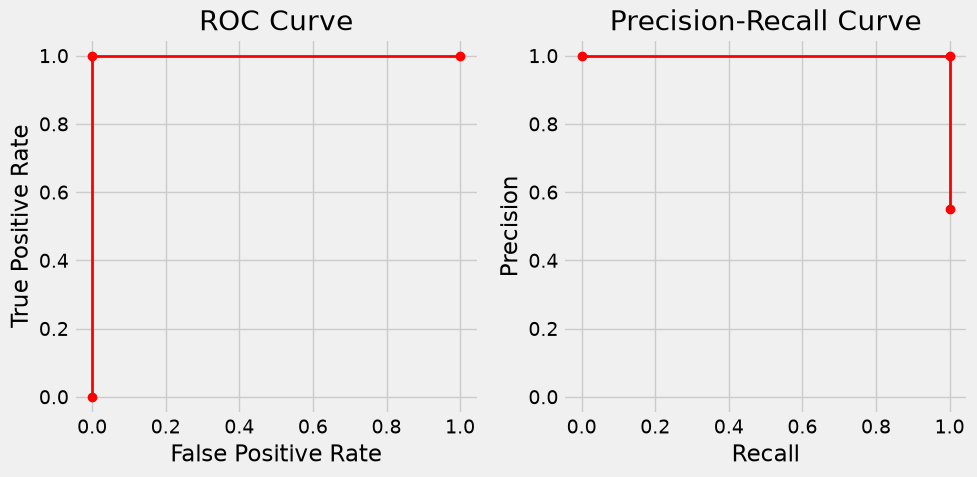

In [36]:
# 可视化最好情况曲线
fig = figure20(y_val)

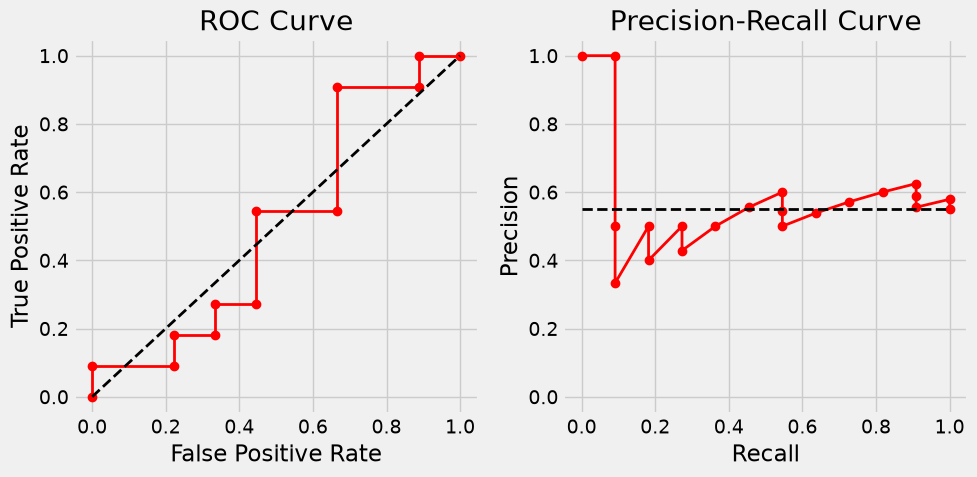

In [37]:
# 可视化最坏的曲线

# 随机猜结果
np.random.seed(39)
random_probs = np.random.uniform(size=y_val.shape)

fpr_random, tpr_random, thresholds1_random = roc_curve(y_val, random_probs)
prec_random, rec_random, thresholds2_random = precision_recall_curve(y_val, random_probs)

# 注意黑线是理论最差情况
fig = figure21(y_val, random_probs)

## 对比各个模型

**Q**: 如何通过曲线评判模型的表现？

结合代码:

**Q**: auc是什么函数？

**Q**: 哪个模型好？

In [38]:
# 程序3-20: 评判模型

auroc = auc(fpr, tpr)
aupr = auc(rec, prec)
print(auroc, aupr)

auroc_random = auc(fpr_random, tpr_random)
aupr_random = auc(rec_random, prec_random)
print(auroc_random, aupr_random)

0.9797979797979798 0.9854312354312356
0.505050505050505 0.570559046216941


# 总结

In [39]:
# 程序3-21:整体流程

# 程序3-1: 生成分类数据
# 程序3-13: 模型配置
# 程序3-14: 模型训练

# 程序3-22: 预测和评估

logits_val = sbs.predict(x_val)
probabilities_val = sigmoid(logits_val).squeeze()

cm_thresh50 = confusion_matrix(y_val,(probabilities_val>=0.5))

print(cm_thresh50)

[[ 7  2]
 [ 1 10]]
